Recurrent Neural Networks (RNN)

Recurrent Neural Networks (RNN) are a type of neural networks designed to process data that follows a sequential order. In conventional neural networks, such as feedforward networks, information flows in one direction, from input to output through hidden layers, without considering the sequential structure of the data. In contrast, RNNs maintain internal states or memories, which allow them to remember past information and use it to predict future data in the sequence.

In [26]:
# Warning configuration
# ==============================================================================
import warnings
warnings.filterwarnings('once')

In [1]:
# Data processing
# ==============================================================================
import os
import pandas as pd
import numpy as np
from skforecast.datasets import fetch_dataset

# Plotting
# ==============================================================================
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)

# Data
import yfinance as yf


In [28]:
# Time series modeling
# ==============================================================================

os.environ["KERAS_BACKEND"] = "tensorflow"  # 'tensorflow', 'jax´ or 'torch'
import keras
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Feature engineering
# ==============================================================================
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from feature_engine.datetime import DatetimeFeatures
from feature_engine.creation import CyclicalFeatures

# Time series modeling
# ==============================================================================
import skforecast
from skforecast.plot import set_dark_theme
from skforecast.datasets import fetch_dataset
from skforecast.deep_learning import ForecasterRnn
from skforecast.deep_learning import create_and_compile_model
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import backtesting_forecaster_multiseries
from skforecast.plot import plot_prediction_intervals

# Warning configuration
# ==============================================================================
import warnings
warnings.filterwarnings('once')
warnings.filterwarnings('ignore', category=DeprecationWarning, module='tensorflow.python.framework.ops')

In [29]:
Ticker='AAPL'  # S&P 500 Index

In [30]:
data = yf.download(Ticker, start='2015-05-30', end='2025-11-04')

[*********************100%***********************]  1 of 1 completed


In [31]:
Ticker_ = pd.DataFrame(data)
#remove second index from the columns
Ticker_.columns = data.columns.droplevel(1)

data.index = pd.to_datetime(data.index)
Ticker_.dropna(inplace=True)


In [32]:
# Add SMA
for sma_period in [5, 10, 20, 50, 100, 200]:
    Ticker_[f'SMA_{sma_period}'] = Ticker_['Close'].rolling(sma_period).mean()

In [33]:
# Add Bollinger Bands
for band in [10, 20]:
    Ticker_[f'BollingerBand_Up_{band}_2'] = Ticker_['Close'].rolling(band).mean() + 2 * Ticker_['Close'].rolling(band).std()
    Ticker_[f'BollingerBand_Down_{band}_2'] = Ticker_['Close'].rolling(band).mean() - 2 * Ticker_['Close'].rolling(band).std()

In [34]:
# Add Donchian Channels
for channel_period in [5, 10, 20, 50, 100, 200]:
    Ticker_[f'Donchian_Channel_Up_{channel_period}'] = Ticker_['High'].rolling(channel_period).max()
    Ticker_[f'Donchian_Channel_Down_{channel_period}'] = Ticker_['Low'].rolling(channel_period).min()

In [35]:
# add historical volatility over 10, 20, 50, 100, 200 days
for vol_period in [10, 20, 50, 100, 200]:
    Ticker_[f'Historical_Volatility_{vol_period}'] = Ticker_['Close'].rolling(vol_period).std()

In [36]:
Ticker_.dropna(inplace=True)

In [37]:
# convert Ticker_ to a dataframe with a datetime index
Ticker_ = pd.DataFrame(Ticker_)
Ticker_.index = pd.to_datetime(Ticker_.index)

In [38]:
print(Ticker_.head())

Price           Close       High        Low       Open     Volume      SMA_5  \
Date                                                                           
2016-03-15  23.707493  23.843508  23.542007  23.566943  160270800  23.197432   
2016-03-16  24.022589  24.099663  23.709752  23.714287  153214000  23.417324   
2016-03-17  23.984060  24.135944  23.793638  23.920585  137682800  23.627242   
2016-03-18  24.011257  24.142739  23.845773  24.106468  176820800  23.793180   
2016-03-21  24.008993  24.403437  23.834439  24.013526  142010800  23.946878   

Price          SMA_10     SMA_20     SMA_50    SMA_100  ...  \
Date                                                    ...   
2016-03-15  23.118317  22.542178  22.187638  24.065397  ...   
2016-03-16  23.236650  22.631155  22.193026  24.050222  ...   
2016-03-17  23.334128  22.739287  22.209549  24.030756  ...   
2016-03-18  23.400096  22.851273  22.235680  24.003525  ...   
2016-03-21  23.491680  22.953625  22.280930  23.984802  ...  

In [39]:
# Fetch dividend history
dividends = yf.Ticker(Ticker).dividends
print(dividends.tail())

Date
2024-11-08 00:00:00-05:00    0.25
2025-02-10 00:00:00-05:00    0.25
2025-05-12 00:00:00-04:00    0.26
2025-08-11 00:00:00-04:00    0.26
2025-11-10 00:00:00-05:00    0.26
Name: Dividends, dtype: float64


In [40]:
recommendations_ = yf.Ticker(Ticker).get_upgrades_downgrades()
# If the index is not datetime, convert it
if not pd.api.types.is_datetime64_any_dtype(recommendations_.index):
	recommendations_.index = pd.to_datetime(recommendations_.index)
# set date without time
recommendations_.index = recommendations_.index.normalize()

print(recommendations_)

                     Firm      ToGrade    FromGrade Action priceTargetAction  \
GradeDate                                                                      
2025-11-04     Rosenblatt      Neutral      Neutral   main         Maintains   
2025-10-31    Wells Fargo   Overweight   Overweight   main            Raises   
2025-10-31       Barclays  Underweight  Underweight   main            Raises   
2025-10-31      Citigroup          Buy          Buy   main            Raises   
2025-10-31      JP Morgan   Overweight   Overweight   main            Raises   
...                   ...          ...          ...    ...               ...   
2017-03-24        Needham          Buy   Strong Buy   down            Raises   
2017-03-21      Bernstein   Outperform   Outperform   main            Raises   
2017-03-06      Citigroup          Buy                main            Raises   
2017-03-01           BTIG          Buy          Buy   main            Raises   
2012-09-12  Hudson Square          Buy  

In [41]:
# Pivot priceTargetAction per date with count
# This will create a DataFrame with dates as index and counts of each action type
recommendations_.pivot_table(index='GradeDate', columns='priceTargetAction', aggfunc='size', fill_value=0)
# Convert the pivoted DataFrame to a DataFrame with a single column for each action type
recommendations_pivoted = recommendations_.pivot_table(index='GradeDate', columns='priceTargetAction', aggfunc='size', fill_value=0).reset_index()
# Rename the columns to have a more descriptive name
recommendations_pivoted.columns = ['Date'] + [f'{col}' for col in recommendations_pivoted.columns[1:]]
print(recommendations_pivoted.tail())


          Date     Adjusts  Announces  Lowers  Maintains  Raises
529 2025-10-27  0        0          0       0          0       1
530 2025-10-28  0        0          0       0          0       1
531 2025-10-29  0        0          0       0          0       1
532 2025-10-31  0        0          0       0          0      14
533 2025-11-04  0        0          0       0          1       0


In [42]:
# Remove timezone from dividends index
dividends.index = dividends.index.tz_localize(None)

# Drop the existing Dividends column if it exists
if 'Dividends' in Ticker_.columns:
    Ticker_.drop(columns=['Dividends'], inplace=True)

# Add dividends to Ticker_
Ticker_ = Ticker_.join(dividends.rename('Dividends'), how='left')

# Fill NaN values in Dividends with 0
Ticker_['Dividends'] = Ticker_['Dividends'].fillna(0)

In [43]:
print(Ticker_.head())

                Close       High        Low       Open     Volume      SMA_5  \
Date                                                                           
2016-03-15  23.707493  23.843508  23.542007  23.566943  160270800  23.197432   
2016-03-16  24.022589  24.099663  23.709752  23.714287  153214000  23.417324   
2016-03-17  23.984060  24.135944  23.793638  23.920585  137682800  23.627242   
2016-03-18  24.011257  24.142739  23.845773  24.106468  176820800  23.793180   
2016-03-21  24.008993  24.403437  23.834439  24.013526  142010800  23.946878   

               SMA_10     SMA_20     SMA_50    SMA_100  ...  \
Date                                                    ...   
2016-03-15  23.118317  22.542178  22.187638  24.065397  ...   
2016-03-16  23.236650  22.631155  22.193026  24.050222  ...   
2016-03-17  23.334128  22.739287  22.209549  24.030756  ...   
2016-03-18  23.400096  22.851273  22.235680  24.003525  ...   
2016-03-21  23.491680  22.953625  22.280930  23.984802  ...  

In [44]:
# Add recommendations_pivoted to Ticker_
Ticker_ = Ticker_.join(recommendations_pivoted.set_index('Date'), how='left')
# Fill NaN values in recommendations with 0
Ticker_.fillna(0, inplace=True)
# Convert the Date index to datetime if it's not already
Ticker_.index = pd.to_datetime(Ticker_.index)
# Ensure the index is sorted
Ticker_.sort_index(inplace=True)


In [45]:
Ticker_

,Close,High,Low,Open,Volume,SMA_5,SMA_10,SMA_20,SMA_50,SMA_100,...,Historical_Volatility_50,Historical_Volatility_100,Historical_Volatility_200,Dividends,,Adjusts,Announces,Lowers,Maintains,Raises
Date,,,,,,,,,,,,,,,,,,,,,
2016-03-15,23.707493,23.843508,23.542007,23.566943,160270800,23.197432,23.118317,22.542178,22.187638,24.065397,...,0.698447,2.087023,2.263674,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-03-16,24.022589,24.099663,23.709752,23.714287,153214000,23.417324,23.236650,22.631155,22.193026,24.050222,...,0.711686,2.081703,2.249007,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-03-17,23.984060,24.135944,23.793638,23.920585,137682800,23.627242,23.334128,22.739287,22.209549,24.030756,...,0.743426,2.073024,2.235171,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-03-18,24.011257,24.142739,23.845773,24.106468,176820800,23.793180,23.400096,22.851273,22.235680,24.003525,...,0.783090,2.054957,2.220574,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-03-21,24.008993,24.403437,23.834439,24.013526,142010800,23.946878,23.491680,22.953625,22.280930,23.984802,...,0.818800,2.046187,2.207050,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-28,268.739471,269.628624,267.890289,268.729471,41534800,263.476581,259.023897,256.217621,245.410498,227.596135,...,12.702463,21.252259,19.912749,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2025-10-29,269.438812,271.147148,266.851294,269.019206,51086700,265.724402,261.057925,256.929431,246.192540,228.255607,...,12.956629,21.518252,20.175727,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2025-10-30,271.137146,273.874513,268.219991,271.726571,69886500,268.086115,263.450604,257.642239,247.099461,228.956711,...,13.085844,21.762896,20.456411,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
print(Ticker_.tail())

                 Close        High         Low        Open    Volume  \
Date                                                                   
2025-10-28  268.739471  269.628624  267.890289  268.729471  41534800   
2025-10-29  269.438812  271.147148  266.851294  269.019206  51086700   
2025-10-30  271.137146  273.874513  268.219991  271.726571  69886500   
2025-10-31  270.108154  277.051436  268.899335  276.721738  86167100   
2025-11-03  268.789429  270.587704  265.992153  270.158128  50194600   

                 SMA_5      SMA_10      SMA_20      SMA_50     SMA_100  ...  \
Date                                                                    ...   
2025-10-28  263.476581  259.023897  256.217621  245.410498  227.596135  ...   
2025-10-29  265.724402  261.057925  256.929431  246.192540  228.255607  ...   
2025-10-30  268.086115  263.450604  257.642239  247.099461  228.956711  ...   
2025-10-31  269.594647  265.256854  258.259142  248.007980  229.635351  ...   
2025-11-03  269.64260

In [25]:
# Ensure the index is a datetime index
#Ticker_.index = pd.to_datetime(Ticker_.index)

# Set the frequency to business days (or another frequency, e.g., daily, monthly)
#Ticker_ = Ticker_.asfreq('B')  # 'B' stands for business days

In [ ]:
# Split train-validation-test
# ==============================================================================
Ticker_ = Ticker_.loc[:'2025-11-04', :].copy()
end_train = "2023-06-29"
end_validation = "2024-12-29"
Ticker_val = Ticker_.loc[:end_train, :].copy()
Ticker_val = Ticker_.loc[end_train:end_validation, :].copy()
Ticker_test = Ticker_.loc[end_validation:, :].copy()

print(
    f"Dates train      : {Ticker_val.index.min()} --- " 
    f"{Ticker_val.index.max()}  (n={len(Ticker_val)})"
)
print(
    f"Dates validation : {Ticker_val.index.min()} --- " 
    f"{Ticker_val.index.max()}  (n={len(Ticker_val)})"
)
print(
    f"Dates test       : {Ticker_test.index.min()} --- " 
    f"{Ticker_test.index.max()}  (n={len(Ticker_test)})"
)

Dates train      : 2016-03-15 00:00:00 --- 2023-06-29 00:00:00  (n=1836)
Dates validation : 2023-06-29 00:00:00 --- 2024-12-27 00:00:00  (n=378)
Dates test       : 2024-12-30 00:00:00 --- 2025-11-03 00:00:00  (n=212)


In [ ]:
# Plotting Close price (rolling mean) for train, validation, and test using Plotly
import plotly.graph_objs as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=Ticker_val.index,
    y=Ticker_val["Close"].rolling(20).mean(),
    mode='lines',
    name='train'
))
fig.add_trace(go.Scatter(
    x=Ticker_val.index,
    y=Ticker_val["Close"].rolling(20).mean(),
    mode='lines',
    name='validation'
))
fig.add_trace(go.Scatter(
    x=Ticker_test.index,
    y=Ticker_test["Close"].rolling(20).mean(),
    mode='lines',
    name='test'
))

fig.update_layout(
    title="AAPL Close Price (100-day Rolling Mean)",
    xaxis_title="Date",
    yaxis_title="Close (100d MA)",
    template="seaborn"
)

fig.show()

/var/folders/9w/p1vsc7s93518tcxwptc20kbr0000gn/T/ipykernel_1159/2114449055.py:22: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

/var/folders/9w/p1vsc7s93518tcxwptc20kbr0000gn/T/ipykernel_1159/2114449055.py:28: UserWarning:

Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.



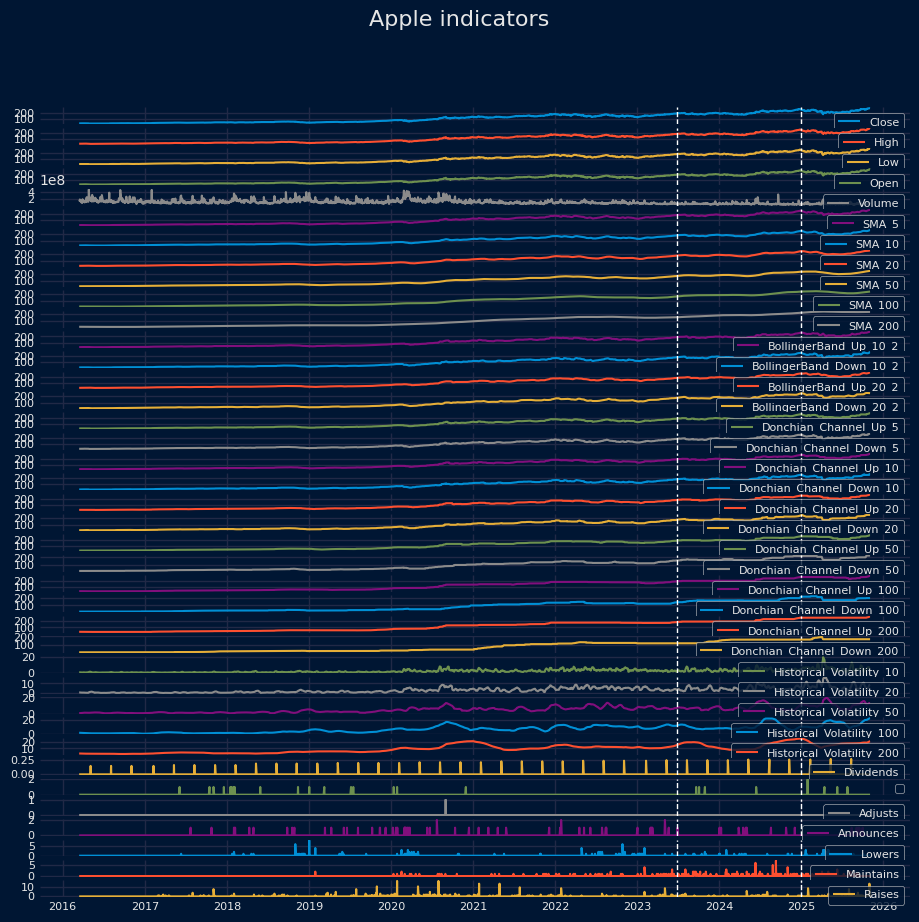

In [49]:
# Plot series
# ==============================================================================
set_dark_theme()
import itertools

n_cols = len(Ticker_.columns)

# create a colors list that covers all columns (repeating if necessary)
base_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = list(itertools.islice(itertools.cycle(base_colors), n_cols))

# adjust figure height to better accommodate many subplots
fig_height = max(6, 0.25 * n_cols)  # scale height with number of series
fig, axes = plt.subplots(n_cols, 1, figsize=(10, fig_height), sharex=True)

# ensure axes is always an array (handles the single-axis case)
axes = np.atleast_1d(axes)

for i, col in enumerate(Ticker_.columns):
    ax = axes[i]
    ax.plot(Ticker_[col], label=col, color=colors[i])
    ax.legend(loc='upper right', fontsize=8)
    ax.tick_params(axis='both', labelsize=8)
    ax.axvline(pd.to_datetime(end_train), color='white', linestyle='--', linewidth=1)  # End train
    ax.axvline(pd.to_datetime(end_validation), color='white', linestyle='--', linewidth=1)  # End validation

fig.suptitle("Apple indicators", fontsize=16)
plt.tight_layout()
plt.show()

Building RNN-based models easily with create_and_compile_model



skforecast provides the utility function create_and_compile_model to simplify the creation of recurrent neural network architectures (RNN, LSTM, or GRU) for time series forecasting. This function is designed to make it easy for both beginners and advanced users to build and compile Keras models with just a few lines of code.

Basic usage

For most forecasting scenarios, you can simply specify the time series data, the number of lagged observations, the number of steps to predict, and the type of recurrent layer you wish to use (LSTM, GRU, or SimpleRNN). By default, the function sets reasonable parameters for each layer, but all architectural details can be adjusted to fit specific requirements.

In [50]:
# Basic usage of `create_and_compile_model`
# ==============================================================================
model = create_and_compile_model(
            series          = Ticker_,    # All 10 series are used as predictors
            levels          = ["Close"],  # Target series to predict
            lags            = 32,      # Number of lags to use as predictors
            steps           = 24,      # Number of steps to predict
            recurrent_layer = "LSTM",  # Type of recurrent layer ('LSTM', 'GRU', or 'RNN')
            recurrent_units = 100,     # Number of units in the recurrent layer
            dense_units     = 64       # Number of units in the dense layer
        )

model.summary()

keras version: 3.7.0
Using backend: tensorflow
tensorflow version: 2.16.2



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ series_input (InputLayer)       │ (None, 32, 39)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        56,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_td_layer (Dense)   │ (None, 24)             │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 24, 1)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,024 (250.09 KB)

 Trainable params: 64,024 (250.09 KB)

 Non-trainable params: 0 (0.00 B)

Advanced customization



All arguments controlling layer types, units, activations, and other options can be customized. You may also pass your own Keras model if you need full flexibility beyond what the helper function provides.

The arguments recurrent_layers_kwargs and dense_layers_kwargs allow you to specify the parameters for the recurrent and dense layers, respectively.

When using a dictionary, the kwargs are replayed for each layer of the same type. For example, if you specify recurrent_layers_kwargs = {'activation': 'tanh'}, all recurrent layers will use the tanh activation function.

You can also pass a list of dictionaries to specify different parameters for each layer. For instance, recurrent_layers_kwargs = [{'activation': 'tanh'}, {'activation': 'relu'}] will specify that the first recurrent layer uses the tanh activation function and the second uses relu.

In [51]:
# Advance usage of `create_and_compile_model`
# ==============================================================================
model = create_and_compile_model(
    series                    = Ticker_,
    levels                    = ["Close"], 
    lags                      = 32,
    steps                     = 24,
    exog                      = None,  # No exogenous variables
    recurrent_layer           = "LSTM",    
    recurrent_units           = [128, 64],  
    recurrent_layers_kwargs   = [{'activation': 'tanh'}, {'activation': 'relu'}],
    dense_units               = [128, 64],
    dense_layers_kwargs       = {'activation': 'relu'},
    output_dense_layer_kwargs = {'activation': 'linear'},
    compile_kwargs            = {'optimizer': Adam(learning_rate=0.001), 'loss': MeanSquaredError()},
    model_name                = None
)

model.summary()

keras version: 3.7.0
Using backend: tensorflow
tensorflow version: 2.16.2



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ series_input (InputLayer)       │ (None, 32, 39)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32, 128)        │        86,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_td_layer (Dense)   │ (None, 24)             │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 24, 1)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,560 (599.84 KB)

 Trainable params: 153,560 (599.84 KB)

 Non-trainable params: 0 (0.00 B)

Problems — Single-series, single-output


In this scenario, the goal is to predict the next value in a single time series, using only its own past observations as predictors. This is known as a univariate autoregressive forecasting problem.


Single-step forecasting


This is the simplest scenario for forecasting with recurrent neural networks: both training and prediction are based on a single time series. In this case, you simply pass that series to the series argument of the create_and_compile_model function, and set the same series as the target using the levels argument. Since you want to predict only one value in the future, set the steps parameter to 1.

In [52]:
# Create model
# ==============================================================================
lags = 24

model = create_and_compile_model(
    series                  = Ticker_[["Close"]],  # Only the 'Close' series is used as predictor
    levels                  = ["Close"],        # Target series to predict
    lags                    = lags,          # Number of lags to use as predictors
    steps                   = 1,             # Single-step forecasting
    recurrent_layer         = "GRU",
    recurrent_units         = 64,
    recurrent_layers_kwargs = {"activation": "tanh"},
    dense_units             = 32,
    compile_kwargs          = {'optimizer': Adam(), 'loss': MeanSquaredError()},
    model_name              = "Single-Series-Single-Step" 
)

model.summary()


keras version: 3.7.0
Using backend: tensorflow
tensorflow version: 2.16.2



Model: "Single-Series-Single-Step"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ series_input (InputLayer)       │ (None, 24, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_td_layer (Dense)   │ (None, 1)              │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

The forecaster is created using the model, and validation data is provided so that the model’s performance can be evaluated at each epoch. A MinMaxScaler is also used to standardize the input and output data. This scaler handles scaling for both training and predictions, ensuring results are brought back to their original scale.

The fit_kwargs dictionary contains the parameters passed to the model’s fit method. In this example, it specifies the number of training epochs, batch size, validation data, and an EarlyStopping callback, which stops training if the validation loss does not improve.

In [ ]:
print(Ticker_val[['Close']].isna().sum())

Close    0
dtype: int64


In [ ]:
# Ensure the index is a DatetimeIndex
Ticker_val.index = pd.to_datetime(Ticker_val.index)

# Set the frequency to business days (or another appropriate frequency)
Ticker_val = Ticker_val.asfreq('B')  # 'B' stands for business days

# Handle missing values if any are introduced
Ticker_val = Ticker_val.ffill()  # Forward-fill missing values

In [65]:
# Ensure the index is a DatetimeIndex
Ticker_val.index = pd.to_datetime(Ticker_val.index)

# Set the frequency to business days (or another appropriate frequency)
Ticker_val = Ticker_val.asfreq('B')  # 'B' stands for business days

# Handle missing values if any are introduced
Ticker_val = Ticker_val.ffill()  # Forward-fill missing values

In [66]:
print(Ticker_train.index.freq)

<BusinessDay>


In [67]:
print(Ticker_val.index.freq)

<BusinessDay>


In [68]:
# Forecaster Creation
# ==============================================================================
forecaster = ForecasterRnn(
    regressor=model,
    levels=["Close"],
    lags=lags,  # Must be same lags as used in create_and_compile_model
    transformer_series=MinMaxScaler(),
    fit_kwargs={
        "epochs": 25,       # Number of epochs to train the model.
        "batch_size": 512,  # Batch size to train the model.
        "callbacks": [
            EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
        ],  # Callback to stop training when it is no longer learning.
        "series_val": Ticker_val,  # Validation data for model training.
    },
)

# Fit forecaster
# ==============================================================================
forecaster.fit(Ticker_train[['Close']])
forecaster

/Users/Massimiliano/anaconda3/envs/Environment3_15/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 2 variables. 



Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.1927 - val_loss: 0.1765
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - loss: 0.1765 - val_loss: 0.1612
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - loss: 0.1612 - val_loss: 0.1463
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - loss: 0.1463 - val_loss: 0.1309
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - loss: 0.1309 - val_loss: 0.1157
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - loss: 0.1157 - val_loss: 0.1014
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - loss: 0.1014 - val_loss: 0.0891
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - loss: 0.0891 - val_loss: 0.0778
Epoch 9/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - loss: 0.0778 - val_loss: 0.0669
Epoch 10/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step - loss: 0.0669 - val_loss: 0.0563
Epoch 11/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - loss: 0.0563 - val_loss: 0.0462
Epoch 12/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - loss: 0.0462 - val_loss:

============= 
ForecasterRnn 
============= 
Regressor: <Functional name=Single-Series-Single-Step, built=True> 
Layers names: ['series_input', 'gru_1', 'dense_1', 'output_dense_td_layer', 'reshape'] 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window size: 24 
Maximum steps to predict: [1] 
Series names: Close 
Target series (levels): ['Close'] 
Exogenous included: False 
Exogenous names: None 
Transformer for series: MinMaxScaler() 
Transformer for exog: MinMaxScaler() 
Training range: [Timestamp('2023-06-29 00:00:00'), Timestamp('2024-12-27 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: B 
Regressor parameters: {'name': 'Single-Series-Single-Step', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 24, 1), 'dtype': 'float32', 'sparse': False, 'name': 'series_input'}, 'registered_name': None, 'name': 'series_input', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'GRU', 'config': {'name': 'gru_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'return_sequences': False, 'return_state': False, 'go_backwards': False, 'stateful': False, 'unroll': False, 'zero_output_for_mask': False, 'units': 64, 'activation': 'tanh', 'recurrent_activation': 'sigmoid', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'recurrent_initializer': {'module': 'keras.initializers', 'class_name': 'Orthogonal', 'config': {'seed': None, 'gain': 1.0}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'recurrent_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'recurrent_constraint': None, 'bias_constraint': None, 'dropout': 0.0, 'recurrent_dropout': 0.0, 'reset_after': True, 'seed': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 24, 1]}, 'name': 'gru_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 24, 1), 'dtype': 'float32', 'keras_history': ['series_input', 0, 0]}},), 'kwargs': {'training': False, 'mask': None}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_1', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 32, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64]}, 'name': 'dense_1', 'inbound_nodes': [{'args': ({'class_name': '__keras_tensor__', 'config': {'shape': (None, 64), 'dtype': 'float32', 'keras_history': ['gru_1', 0, 0]}},), 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'output_dense_td_layer', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}, 'units': 1, 'activation': 'linear', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 32]

In deep learning models, it’s important to control overfitting, when a model performs well on training data but poorly on new, unseen data. One common approach is to use a Keras callback, such as EarlyStopping, which halts training if the validation loss stops improving.

Another useful practice is to plot the training and validation loss after each epoch. This helps you visualize how the model is learning and spot signs of overfitting.

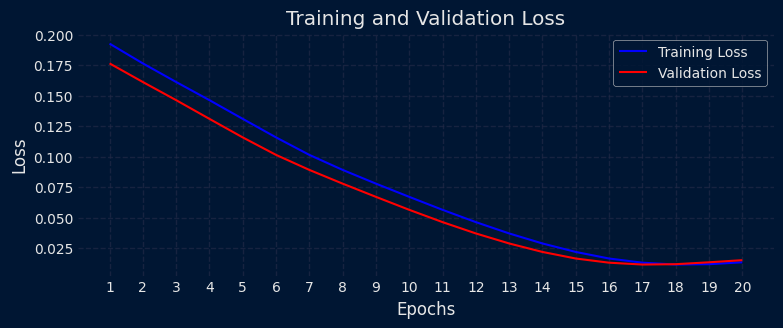

In [69]:
# Track training and overfitting
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 3))
_ = forecaster.plot_history(ax=ax)

Once the forecaster has been trained, predictions can be obtained. If the steps parameter is set to None in the predict method, the forecaster will predict all available steps, forecaster.max_step.

In [70]:
# Forecaster available steps
# ==============================================================================
forecaster.max_step


1

In [71]:
# Predictions
# ==============================================================================# Predictions
# ==============================================================================
predictions = forecaster.predict(steps=None)  # Same as steps=1
predictions


,level,pred
2024-12-30,Close,237.780457


In time series forecasting, the process of backtesting consists of evaluating the performance of a predictive model by applying it retrospectively to historical data. Therefore, it is a special type of cross-validation applied to the previous period(s). To learn more about backtesting, visit the backtesting user guide.

In [77]:
# Ensure the index is a DatetimeIndex
Ticker_.index = pd.to_datetime(Ticker_.index)

# Set the frequency to business days (or another appropriate frequency)
Ticker_ = Ticker_.asfreq('B')  # 'B' stands for business days

# Handle missing values if any are introduced
Ticker_ = Ticker_.ffill()  # Forward-fill missing values

In [78]:
# Backtesting with test data
# ==============================================================================
cv = TimeSeriesFold(
         steps              = forecaster.max_step,
         initial_train_size = len(Ticker_.loc[:end_validation, :]),  # Training + Validation Data
         refit              = False
     )

metrics, predictions = backtesting_forecaster_multiseries(
    forecaster  = forecaster,
    series      = Ticker_[['Close']],
    cv          = cv,
    levels      = forecaster.levels,
    metric      = "mean_absolute_error",
    verbose     = False  # Set to True for detailed output
)

Epoch 1/25


5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 456ms/step - loss: 0.0104 - val_loss: 0.0018
Epoch 2/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 241ms/step - loss: 0.0076 - val_loss: 0.0072
Epoch 3/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step - loss: 0.0042 - val_loss: 0.0068
Epoch 4/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - loss: 0.0020 - val_loss: 3.2628e-04
Epoch 5/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - loss: 8.5391e-04 - val_loss: 2.5007e-04
Epoch 6/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - loss: 2.1250e-04 - val_loss: 2.6608e-04
Epoch 7/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - loss: 2.7283e-04 - val_loss: 0.0014
Epoch 8/25
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 4.1454e-04 - val_loss: 2.5799e-04


  0%|          | 0/221 [00:00<?, ?it/s]

In [79]:
# Backtesting metrics
# ==============================================================================
metrics

,levels,mean_absolute_error
0,Close,4.526557


In [80]:
# Backtesting predictions
# ==============================================================================
predictions.head(4)

,level,fold,pred
2024-12-30,Close,0,255.146255
2024-12-31,Close,1,253.692139
2025-01-01,Close,2,252.050018
2025-01-02,Close,3,250.910400


In [83]:
#Plotting predictions vs real values in the test set
# ==============================================================================
fig = go.Figure()
trace1 = go.Scatter(x=Ticker_test.index, y=Ticker_test['Close'], name="test", mode="lines")
trace2 = go.Scatter(
    x=predictions.index,
    y=predictions.loc[predictions["level"] == "Close", "pred"],
    name="predictions", mode="lines"
)
fig.add_trace(trace1)
fig.add_trace(trace2)
fig.update_layout(
    title="Prediction vs real values in the test set",
    xaxis_title="Date time",
    yaxis_title="Close",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1.05, xanchor="left", x=0)
)
fig.show()

In [85]:
# % Error vs series mean
# ==============================================================================
rel_mse = 100 * metrics.loc[0, 'mean_absolute_error'] / np.mean(Ticker_["Close"])
print(f"Serie mean: {np.mean(Ticker_['Close']):0.2f}")
print(f"Relative error (mae): {rel_mse:0.2f} %")

Serie mean: 113.61
Relative error (mae): 3.98 %


Multi-step forecasting

In this scenario, the objective is to predict multiple future values of a single time series using only its own past observations as predictors. This is known as multi-step univariate forecasting.

This setup is common when you want to forecast several periods into the future (e.g., the next 24 hours of ozone concentration).


Model Architecture

You can use a similar network architecture as in the single-step case, but predicting multiple steps ahead usually benefits from increasing the capacity of the model (e.g., more units in LSTM/GRU layers or additional dense layers). This allows the model to better capture the complexity of forecasting several points at once.

In [87]:
# Create model
# ==============================================================================
lags = 24

model = create_and_compile_model(
    series                  = Ticker_[["Close"]],  # Only the 'o3' series is used as predictor
    levels                  = ["Close"],        # Target series to predict
    lags                    = lags,          # Number of lags to use as predictors
    steps                   = 24,            # Multi-step forecasting
    recurrent_layer         = "GRU",
    recurrent_units         = 128,
    recurrent_layers_kwargs = {"activation": "tanh"},
    dense_units             = 64,
    compile_kwargs          = {'optimizer': 'adam', 'loss': 'mse'},
    model_name              = "Single-Series-Multi-Step" 
)

model.summary()

keras version: 3.7.0
Using backend: tensorflow
tensorflow version: 2.16.2



Model: "Single-Series-Multi-Step"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ series_input (InputLayer)       │ (None, 24, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_td_layer (Dense)   │ (None, 24)             │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 24, 1)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,120 (234.84 KB)

 Trainable params: 60,120 (234.84 KB)

 Non-trainable params: 0 (0.00 B)

The fit_kwargs parameter lets you customize any aspect of the model training process, passing arguments directly to the underlying Keras Model.fit() method. For example, you can specify the number of training epochs, batch size, and any callbacks you want to use. In the code example, the model is trained for 50 epochs with a batch size of 512. The EarlyStopping callback monitors the validation loss and automatically stops training if it does not improve for 3 consecutive epochs (patience=3). This helps prevent overfitting and saves computation time. You can also add other callbacks, such as ModelCheckpoint to save the model at each epoch, or TensorBoard for real-time visualization of training and validation metrics.

In [93]:
# Forecaster Creation
# ==============================================================================
forecaster = ForecasterRnn(
    regressor=model,
    levels=["Close"],
    lags=lags,
    transformer_series=MinMaxScaler(),
    fit_kwargs={
        "epochs": 50, 
        "batch_size": 512, 
        "callbacks": [
            EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)
        ],  # Callback to stop training when it is no longer learning.
        "series_val": Ticker_val,  # Validation data for model training.
    },
)

# Fit forecaster
# ==============================================================================
forecaster.fit(Ticker_train[['Close']])

/Users/Massimiliano/anaconda3/envs/Environment3_15/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 2 variables. 



Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.1914 - val_loss: 0.1799
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1799 - val_loss: 0.1684
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step - loss: 0.1684 - val_loss: 0.1570
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step - loss: 0.1570 - val_loss: 0.1466
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step - loss: 0.1466 - val_loss: 0.1369
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step - loss: 0.1369 - val_loss: 0.1269
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step - loss: 0.1269 - val_loss: 0.1162
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step - loss: 0.1162 - val_loss: 0.1047
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - loss: 0.1047 - val_loss: 0.0925
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - loss: 0.0925 - val_loss: 0.0796
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step - loss: 0.0796 - val_loss: 0.0663
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 843ms/step - loss: 0.0663 - val_loss: 0.

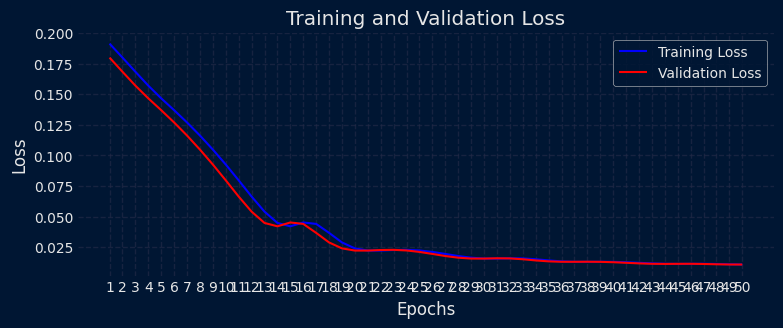

In [94]:
# Train and overfitting tracking
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 3))
_ = forecaster.plot_history(ax=ax)

In this case, the prediction quality is expected to be lower than in the previous example, as shown by the higher loss values across epochs. This is easily explained: the model now has to predict 24 values at each step instead of just 1. As a result, the validation loss is higher, since it reflects the combined error across all 24 predicted values, rather than the error for a single value.

In [95]:
# Forecaster available steps
# ==============================================================================
forecaster.max_step

24

In [96]:
# Prediction
# ==============================================================================
predictions = forecaster.predict(steps=24)  # Same as steps=None
predictions.head(4)

,level,pred
2024-12-30,Close,254.708298
2024-12-31,Close,250.393433
2025-01-01,Close,255.092819
2025-01-02,Close,261.496826


Specific steps can be predicted, as long as they are within the prediction horizon defined in the model.

In [97]:
# Specific step predictions
# ==============================================================================
predictions = forecaster.predict(steps=[1, 3])
predictions

,level,pred
2024-12-30,Close,254.708298
2025-01-01,Close,255.092819


In [98]:
# Backtesting 
# ==============================================================================
cv = TimeSeriesFold(
         steps              = forecaster.max_step,
         initial_train_size = len(Ticker_.loc[:end_validation, :]),  # Training + Validation Data
         refit              = False
     )

metrics, predictions = backtesting_forecaster_multiseries(
    forecaster        = forecaster,
    series            = Ticker_[['Close']],
    cv                = cv,
    levels            = forecaster.levels,
    metric            = "mean_absolute_error",
    verbose           = False,
    suppress_warnings = True
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 540ms/step - loss: 0.0016 - val_loss: 0.0027
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 354ms/step - loss: 0.0013 - val_loss: 0.0032
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 604ms/step - loss: 0.0013 - val_loss: 0.0020
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 621ms/step - loss: 0.0012 - val_loss: 0.0022
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 418ms/step - loss: 0.0011 - val_loss: 0.0018
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 613ms/step - loss: 0.0010 - val_loss: 0.0018
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 853ms/step - loss: 9.9015e-04 - val_loss: 0.0017
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 9.6863e-04 - val_loss: 0.0017
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 696ms/step - loss: 9.5506e-04 - val_loss: 0.0017
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 535ms/step - loss: 9.1812e-04 - val_loss: 0.0017
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 381ms/step - loss: 9.4175e-04 - val_loss: 0.0017
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 334ms/step - loss

  0%|          | 0/10 [00:00<?, ?it/s]

In [99]:
# Backtesting metrics
# ==============================================================================
metric_single_series = metrics.loc[metrics["levels"] == "Close", "mean_absolute_error"].iat[0]
metrics

,levels,mean_absolute_error
0,Close,10.252292


In [100]:
# Backtesting predictions
# ==============================================================================
predictions

,level,fold,pred
2024-12-30,Close,0,257.972229
2024-12-31,Close,0,256.628143
2025-01-01,Close,0,257.755341
2025-01-02,Close,0,257.481232
2025-01-03,Close,0,257.104218
...,...,...,...
2025-10-28,Close,9,263.909607
2025-10-29,Close,9,262.895844
2025-10-30,Close,9,264.369537
2025-10-31,Close,9,263.844910


In [101]:
# Plotting predictions vs real values in the test set
# ==============================================================================
fig = go.Figure()
trace1 = go.Scatter(x=Ticker_test.index, y=Ticker_test['Close'], name="test", mode="lines")
trace2 = go.Scatter(
    x=predictions.index,
    y=predictions.loc[predictions["level"] == "Close", "pred"],
    name="predictions", mode="lines"
)
fig.add_trace(trace1)
fig.add_trace(trace2)
fig.update_layout(
    title="Prediction vs real values in the test set",
    xaxis_title="Date time",
    yaxis_title="Close",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1.05, xanchor="left", x=0)
)
fig.show()

In [102]:
# % Error vs series mean
# ==============================================================================
rel_mse = 100 * metrics.loc[0, 'mean_absolute_error'] / np.mean(Ticker_["Close"])
print(f"Serie mean: {np.mean(Ticker_['Close']):0.2f}")
print(f"Relative error (mae): {rel_mse:0.2f} %")

Serie mean: 113.61
Relative error (mae): 9.02 %


In this case, the prediction is worse than in the previous case. This is to be expected since the model has to predict 24 values instead of 1.